# TabPFN Cross-Grid Transfer: Train Small → Predict Unseen (Pre-PF Features Only)

**Goal**: Train TabPFN on AC power flow data from small IEEE grids (9, 14, 30, 39, 57 buses),
then predict PF solutions on an **unseen** grid (IEEE 118) — a topology never seen during training.

**Critical constraint**: **No AC power flow is run on the test grid.** All input features must be
obtainable from the grid data and specifications alone (topology, line parameters, load/gen setpoints).
AC PF is only used on training grids to obtain target labels.

**Key techniques**:
1. **Pre-PF features only** — use topology, specified injections, impedances, and bus type knowns/unknowns
2. **DC power flow angles** — a non-iterative linear computation ($\theta = B^{-1}P$) as a physics-informed feature
3. **Per-grid normalization** — divide power features by total system load for scale invariance
4. **Residual-from-DC prediction** — predict the AC–DC correction rather than absolute angles
5. **Data augmentation** — solve each training grid at multiple loading conditions

**Training grids**: case9, case14, case30, case39, case57  
**Test grid (unseen)**: case118

In [107]:
import copy
import pandapower as pp
import pandapower.networks as pn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error
import warnings; warnings.filterwarnings('ignore')

## 1. Feature Design: AC Power Flow Knowns & Unknowns

### What does AC power flow solve?

AC power flow is solved using **iterative methods** (Newton-Raphson, Gauss-Seidel). At each bus $i$, the power balance equations are:

$$P_i = V_i \sum_{k=1}^{N} V_k \left[ G_{ik} \cos(\theta_i - \theta_k) + B_{ik} \sin(\theta_i - \theta_k) \right]$$
$$Q_i = V_i \sum_{k=1}^{N} V_k \left[ G_{ik} \sin(\theta_i - \theta_k) - B_{ik} \cos(\theta_i - \theta_k) \right]$$

where $G_{ik} + jB_{ik}$ are elements of the bus admittance matrix $\mathbf{Y}_{\text{bus}}$, built from line and transformer parameters.

### Knowns and unknowns by bus type

| Bus Type | Known (specified before PF) | Unknown (PF solves for) |
|---|---|---|
| **Slack** (reference) | $V_m$, $\theta = 0$ | $P$, $Q$ |
| **PV** (generator) | $P_{\text{gen}}$, $V_m$ | $Q$, $\theta$ |
| **PQ** (load) | $P_{\text{load}}$, $Q_{\text{load}}$ | $V_m$, $\theta$ |

**Key principle**: Our features can ONLY use the "Known" quantities above, plus the network topology and parameters (line impedances, transformer data), which are always available before solving.

### DC power flow as a pre-PF feature

DC power flow is a **non-iterative, linear** computation that estimates bus voltage angles:

$$\boldsymbol{\theta} = \mathbf{B}'^{-1} \mathbf{P}$$

where $\mathbf{B}'$ is the imaginary part of $\mathbf{Y}_{\text{bus}}$ (built from line reactances) and $\mathbf{P}$ is the vector of specified active power injections. This is a single matrix solve — fundamentally different from iterative AC PF. It uses only:
- Network topology and line reactances (pre-PF)
- Specified active power injections (pre-PF)

DC PF provides a good first-order angle estimate that captures most of the angle structure. The **AC–DC residual** ($\theta_{\text{AC}} - \theta_{\text{DC}}$) is typically small and transferable across grids.

### Feature categories

| Category | Examples | Available at test time? |
|---|---|---|
| **Structural** | degree, grid size, bus position | ✓ (from topology) |
| **Specified injections** | load P/Q, gen P, shunt P/Q | ✓ (input specifications) |
| **Voltage setpoints** | gen $V_m$, slack $V_m$, bus type | ✓ (input specifications) |
| **Network impedance** | line $x$, $r$, charging $b$, trafo $v_k$ | ✓ (from line/trafo data) |
| **Generator limits** | $Q_{\min}$, $Q_{\max}$ | ✓ (from gen data) |
| **DC PF angles** | $\theta_{\text{DC}}$ | ✓ (linear algebra from above) |
| ~~Base-case AC PF results~~ | ~~$V^{\text{base}}$, $\theta^{\text{base}}$, $P^{\text{base}}$~~ | ✗ (requires AC PF) |
| ~~Jacobian sensitivities~~ | ~~$\partial\theta/\partial s$, $\partial Q/\partial s$~~ | ✗ (requires AC PF) |

In [108]:
def compute_fdpf_vq(net, theta_dc_deg, n_iter=10):
    """
    Full Fast Decoupled Power Flow solver using pandapower's Y-bus.

    Uses pandapower's internal model to build the correct Y-bus
    (handling tap ratios, trafo models, shunts, etc.), then iterates
    P-θ and Q-V sub-problems.

    Returns: (V, Q_bus_mvar) where Q is from the converged solution.
    Both in pandapower convention (res_bus: positive = consumed).
    """
    from pandapower.pd2ppc import _pd2ppc
    from pandapower.auxiliary import _init_runpp_options
    from pandapower.pypower.makeYbus import makeYbus

    n = len(net.bus)
    bus_list = net.bus.index.tolist()
    bus_to_idx = {b: i for i, b in enumerate(bus_list)}
    S_base = 100.0

    # Build Y-bus using pandapower's converter (handles taps, trafo models, etc.)
    net_copy = copy.deepcopy(net)
    _init_runpp_options(net_copy, algorithm='nr', calculate_voltage_angles=True,
                        init='flat', max_iteration=1, tolerance_mva=1e-8,
                        trafo_model='t', trafo_loading='current',
                        enforce_q_lims=False, check_connectivity=False,
                        voltage_depend_loads=False, consider_line_temperature=False,
                        distributed_slack=False)
    ppc, ppci = _pd2ppc(net_copy)
    Ybus_sparse, _, _ = makeYbus(ppci['baseMVA'], ppci['bus'], ppci['branch'])
    Ybus = Ybus_sparse.toarray()  # complex admittance matrix
    bus_lookup = net_copy._pd2ppc_lookups['bus']  # pp index -> ppc index mapping

    # Map between pandapower bus ordering and ppc ordering
    pp_to_ppc = bus_lookup  # numpy array: ppc_idx = bus_lookup[pp_idx]
    n_ppc = Ybus.shape[0]

    # Bus classification (in ppc ordering)
    ext_set = set(net.ext_grid['bus'].values)
    pv_set = (set(net.gen['bus'].values) if len(net.gen) > 0 else set()) - ext_set
    slack_ppc = [pp_to_ppc[bus_to_idx[b]] for b in ext_set]
    pv_ppc = [pp_to_ppc[bus_to_idx[b]] for b in pv_set]
    pq_ppc = [pp_to_ppc[bus_to_idx[b]] for b in bus_list
              if b not in ext_set and b not in pv_set]
    ptheta_ppc = sorted(set(pv_ppc + pq_ppc))  # all non-slack
    pq_ppc = sorted(pq_ppc)

    # P specification (injection convention, ppc ordering)
    p_spec = np.zeros(n_ppc)
    for row_idx in net.load.index:
        load = net.load.loc[row_idx]
        ppc_i = pp_to_ppc[bus_to_idx[load['bus']]]
        p_spec[ppc_i] -= load['p_mw'] / S_base
    if len(net.gen) > 0:
        for row_idx in net.gen.index:
            gen = net.gen.loc[row_idx]
            ppc_i = pp_to_ppc[bus_to_idx[gen['bus']]]
            p_spec[ppc_i] += gen['p_mw'] / S_base
    if len(net.shunt) > 0:
        for row_idx in net.shunt.index:
            shunt = net.shunt.loc[row_idx]
            ppc_i = pp_to_ppc[bus_to_idx[shunt['bus']]]
            p_spec[ppc_i] -= shunt['p_mw'] / S_base

    # Q specification at PQ buses (injection convention)
    q_spec = np.zeros(n_ppc)
    for row_idx in net.load.index:
        load = net.load.loc[row_idx]
        ppc_i = pp_to_ppc[bus_to_idx[load['bus']]]
        q_spec[ppc_i] -= load['q_mvar'] / S_base
    if len(net.shunt) > 0:
        for row_idx in net.shunt.index:
            shunt = net.shunt.loc[row_idx]
            ppc_i = pp_to_ppc[bus_to_idx[shunt['bus']]]
            q_spec[ppc_i] -= shunt['q_mvar'] / S_base

    # Initial V and θ (ppc ordering)
    theta = np.zeros(n_ppc)
    V = np.ones(n_ppc)
    for pp_idx, bus in enumerate(bus_list):
        ppc_i = pp_to_ppc[pp_idx]
        theta[ppc_i] = np.radians(theta_dc_deg[pp_idx])
    if len(net.gen) > 0:
        for row_idx in net.gen.index:
            gen = net.gen.loc[row_idx]
            ppc_i = pp_to_ppc[bus_to_idx[gen['bus']]]
            V[ppc_i] = gen['vm_pu']
    for row_idx in net.ext_grid.index:
        ext = net.ext_grid.loc[row_idx]
        ppc_i = pp_to_ppc[bus_to_idx[ext['bus']]]
        V[ppc_i] = ext['vm_pu']

    # Build B' and B'' from Y-bus imaginary part
    # Standard FDPF: B' = B'' = -Im(Y_bus) (positive definite for normal grids)
    Bp = -Ybus.imag
    Bp_sub = Bp[np.ix_(ptheta_ppc, ptheta_ppc)]
    Bpp_sub = Bp[np.ix_(pq_ppc, pq_ppc)]

    # FDPF iterations with convergence monitoring
    best_max_mismatch = np.inf
    best_V = V.copy()
    best_theta = theta.copy()
    for iteration in range(n_iter):
        # Compute P_calc, Q_calc from V, θ
        V_complex = V * np.exp(1j * theta)
        S_calc = V_complex * np.conj(Ybus @ V_complex)
        P_calc = S_calc.real
        Q_calc = S_calc.imag

        # P-θ update: all non-slack buses
        dP = p_spec[ptheta_ppc] - P_calc[ptheta_ppc]
        dP_over_V = dP / V[ptheta_ppc]

        # Q-V update: PQ buses only
        dQ = q_spec[pq_ppc] - Q_calc[pq_ppc]
        dQ_over_V = dQ / V[pq_ppc]

        max_mismatch = max(np.max(np.abs(dP)), np.max(np.abs(dQ)))
        if max_mismatch < best_max_mismatch:
            best_max_mismatch = max_mismatch
            best_V = V.copy()
            best_theta = theta.copy()
        elif max_mismatch > 10 * best_max_mismatch:
            # Diverging — revert to best and stop
            V = best_V
            theta = best_theta
            break

        if max_mismatch < 1e-6:
            break  # converged

        try:
            dtheta = np.linalg.solve(Bp_sub, dP_over_V)
            theta[ptheta_ppc] += dtheta
        except np.linalg.LinAlgError:
            pass

        try:
            dV = np.linalg.solve(Bpp_sub, dQ_over_V)
            V[pq_ppc] += dV
        except np.linalg.LinAlgError:
            pass

    # Final S computation
    V_complex = V * np.exp(1j * theta)
    S_final = V_complex * np.conj(Ybus @ V_complex)
    Q_final_ppc = S_final.imag  # injection convention, per-unit

    # Map back to pandapower bus ordering
    v_pp = np.ones(n)
    q_pp = np.zeros(n)
    for pp_idx in range(n):
        ppc_i = pp_to_ppc[pp_idx]
        v_pp[pp_idx] = V[ppc_i]
        # Convert injection → load convention: pandapower res_bus.q_mvar = -Q_injection
        q_pp[pp_idx] = -Q_final_ppc[ppc_i] * S_base

    return v_pp, q_pp


def compute_q_ac_approx(net, v_approx, theta_dc_deg):
    """
    Compute Q at each bus using the full nonlinear AC power flow equation
    with approximate V (from V-Q linearization) and θ (from DC PF).

    Q_i = V_i × Σ_j V_j × (G_ij × sin(θ_i - θ_j) - B_ij × cos(θ_i - θ_j))

    This is NOT iterative — it's a single direct computation.
    Returns q_mvar in load convention (positive = consumed).
    """
    n = len(net.bus)
    bus_list = net.bus.index.tolist()
    bus_to_idx = {b: i for i, b in enumerate(bus_list)}
    S_base = 100.0
    theta = np.radians(theta_dc_deg)

    # Build full Y-bus (G + jB) from lines and trafos
    G = np.zeros((n, n))
    B = np.zeros((n, n))

    for row_idx in net.line.index:
        line = net.line.loc[row_idx]
        if 'in_service' in net.line.columns and not line['in_service']:
            continue
        fi, ti = bus_to_idx[line['from_bus']], bus_to_idx[line['to_bus']]
        vn = net.bus.loc[line['from_bus'], 'vn_kv']
        z_base = vn ** 2 / S_base

        r_ohm = line['r_ohm_per_km'] * line['length_km']
        x_ohm = line['x_ohm_per_km'] * line['length_km']
        r_pu = r_ohm / (z_base + 1e-12)
        x_pu = x_ohm / (z_base + 1e-12)

        z_sq = r_pu**2 + x_pu**2
        if z_sq > 1e-20:
            g_ser = r_pu / z_sq
            b_ser = -x_pu / z_sq
            G[fi, fi] += g_ser; G[ti, ti] += g_ser
            G[fi, ti] -= g_ser; G[ti, fi] -= g_ser
            B[fi, fi] += b_ser; B[ti, ti] += b_ser
            B[fi, ti] -= b_ser; B[ti, fi] -= b_ser

        # Shunt charging susceptance
        b_ch_pu = line['c_nf_per_km'] * line['length_km'] * 1e-9 * 2 * np.pi * 50 * z_base
        B[fi, fi] += b_ch_pu / 2
        B[ti, ti] += b_ch_pu / 2

    for row_idx in net.trafo.index:
        trafo = net.trafo.loc[row_idx]
        if 'in_service' in net.trafo.columns and not trafo['in_service']:
            continue
        hi, li = bus_to_idx[trafo['hv_bus']], bus_to_idx[trafo['lv_bus']]
        vk = trafo['vk_percent'] / 100.0
        vkr = trafo.get('vkr_percent', 0.0) / 100.0
        sn = trafo['sn_mva'] + 1e-12
        z_pu = vk * S_base / sn
        r_pu = vkr * S_base / sn
        x_pu = np.sqrt(max(z_pu**2 - r_pu**2, 1e-20))
        z_sq = r_pu**2 + x_pu**2
        if z_sq > 1e-20:
            g_ser = r_pu / z_sq
            b_ser = -x_pu / z_sq
            G[hi, hi] += g_ser; G[li, li] += g_ser
            G[hi, li] -= g_ser; G[li, hi] -= g_ser
            B[hi, hi] += b_ser; B[li, li] += b_ser
            B[hi, li] -= b_ser; B[li, hi] -= b_ser

    # Add shunt admittances
    if len(net.shunt) > 0:
        for row_idx in net.shunt.index:
            shunt = net.shunt.loc[row_idx]
            bi = bus_to_idx[shunt['bus']]
            vn = net.bus.loc[shunt['bus'], 'vn_kv']
            # Shunt: Y_shunt = P/(V²) + jQ/(V²), in per-unit
            G[bi, bi] += shunt['p_mw'] / S_base
            B[bi, bi] -= shunt['q_mvar'] / S_base

    # Compute Q using AC equation: Q_i = V_i × Σ_j V_j × (G_ij sin(δij) - B_ij cos(δij))
    V = v_approx
    Q_inj = np.zeros(n)
    for i in range(n):
        for j in range(n):
            if G[i, j] != 0 or B[i, j] != 0:
                dtheta = theta[i] - theta[j]
                Q_inj[i] += V[j] * (G[i, j] * np.sin(dtheta) - B[i, j] * np.cos(dtheta))
        Q_inj[i] *= V[i]

    # Convert injection → load convention, pu → MVAr
    q_mvar = -Q_inj * S_base
    return q_mvar


def extract_pre_pf_features(net, load_scale, grid_name=''):
    """
    Extract ONLY pre-PF features from a pandapower net.
    Uses: topology, specified injections, impedances, DC PF angles, linearized V-Q.
    Does NOT use: AC power flow results (res_bus, res_gen, res_load).
    """
    n_bus = len(net.bus)
    bus_info = pd.DataFrame(index=net.bus.index)
    bus_list = net.bus.index.tolist()
    bus_to_idx = {b: i for i, b in enumerate(bus_list)}

    # --- Structural features ---
    bus_info['vn_kv'] = net.bus['vn_kv'].values
    bus_info['bus_pos_norm'] = np.arange(n_bus) / max(n_bus - 1, 1)
    bus_info['grid_n_bus'] = n_bus

    from_counts = net.line['from_bus'].value_counts()
    to_counts = net.line['to_bus'].value_counts()
    line_degree = from_counts.add(to_counts, fill_value=0)
    if len(net.trafo) > 0:
        hv_counts = net.trafo['hv_bus'].value_counts()
        lv_counts = net.trafo['lv_bus'].value_counts()
        total_degree = line_degree.add(hv_counts.add(lv_counts, fill_value=0), fill_value=0)
    else:
        total_degree = line_degree
    bus_info['n_connections'] = total_degree.reindex(bus_info.index, fill_value=0).astype(int)

    # --- Load info ---
    load_per_bus = net.load.groupby('bus').agg(
        nominal_p_mw=('p_mw', 'sum'), nominal_q_mvar=('q_mvar', 'sum'))
    bus_info = bus_info.join(load_per_bus, how='left').fillna(0.0)

    # --- Generator info ---
    if len(net.gen) > 0:
        gen_per_bus = net.gen.groupby('bus').agg(
            gen_p_mw=('p_mw', 'sum'), gen_vm_pu=('vm_pu', 'mean'))
        bus_info = bus_info.join(gen_per_bus, how='left').fillna(0.0)
    else:
        bus_info['gen_p_mw'] = 0.0; bus_info['gen_vm_pu'] = 0.0

    # --- Slack ---
    ext_grid_buses = set(net.ext_grid['bus'].values)
    bus_info['is_slack'] = bus_info.index.isin(ext_grid_buses).astype(int)
    ext_grid_vm = net.ext_grid.groupby('bus').agg(ext_grid_vm_pu=('vm_pu', 'mean'))
    bus_info = bus_info.join(ext_grid_vm, how='left').fillna(0.0)

    # --- Shunt ---
    if len(net.shunt) > 0:
        shunt_per_bus = net.shunt.groupby('bus').agg(
            shunt_p_mw=('p_mw', 'sum'), shunt_q_mvar=('q_mvar', 'sum'))
        bus_info = bus_info.join(shunt_per_bus, how='left').fillna(0.0)
    else:
        bus_info['shunt_p_mw'] = 0.0; bus_info['shunt_q_mvar'] = 0.0
    bus_info['has_shunt'] = ((bus_info['shunt_p_mw'] != 0) | (bus_info['shunt_q_mvar'] != 0)).astype(int)

    # --- Bus type (TOPOLOGICAL ONLY) ---
    gen_buses = set(net.gen['bus'].values) if len(net.gen) > 0 else set()
    gen_buses |= ext_grid_buses
    bus_info['has_gen'] = bus_info.index.isin(gen_buses).astype(int)
    load_buses = set(net.load['bus'].values)
    bus_info['has_load'] = bus_info.index.isin(load_buses).astype(int)

    pv_buses = set(net.gen['bus'].values) if len(net.gen) > 0 else set()
    bus_type_arr = np.zeros(n_bus, dtype=int)
    bus_type_arr[bus_info.index.isin(pv_buses)] = 1
    bus_type_arr[bus_info.index.isin(ext_grid_buses)] = 2
    bus_info['bus_type'] = bus_type_arr

    # --- Specified voltage magnitude ---
    vm_from_ext = bus_info['ext_grid_vm_pu'].values
    vm_from_gen = bus_info['gen_vm_pu'].values
    specified_vm = np.where(vm_from_ext > 0, vm_from_ext,
                   np.where(vm_from_gen > 0, vm_from_gen, 1.0))
    bus_info['specified_vm_pu'] = specified_vm

    # --- Neighbor voltage features (1-hop average of specified_vm) ---
    adj_v_sum = np.zeros(n_bus)
    adj_count = np.zeros(n_bus)
    for _, line in net.line.iterrows():
        fi, ti = bus_to_idx[line['from_bus']], bus_to_idx[line['to_bus']]
        adj_v_sum[fi] += specified_vm[ti]; adj_count[fi] += 1
        adj_v_sum[ti] += specified_vm[fi]; adj_count[ti] += 1
    if len(net.trafo) > 0:
        for _, trafo in net.trafo.iterrows():
            hi, li = bus_to_idx[trafo['hv_bus']], bus_to_idx[trafo['lv_bus']]
            adj_v_sum[hi] += specified_vm[li]; adj_count[hi] += 1
            adj_v_sum[li] += specified_vm[hi]; adj_count[li] += 1
    bus_info['avg_neighbor_vm'] = np.where(adj_count > 0, adj_v_sum / adj_count, 1.0)
    bus_info['frac_gen_neighbors'] = np.zeros(n_bus)
    adj_gen_count = np.zeros(n_bus)
    for _, line in net.line.iterrows():
        fi, ti = bus_to_idx[line['from_bus']], bus_to_idx[line['to_bus']]
        if bus_info.iloc[ti]['has_gen']: adj_gen_count[fi] += 1
        if bus_info.iloc[fi]['has_gen']: adj_gen_count[ti] += 1
    if len(net.trafo) > 0:
        for _, trafo in net.trafo.iterrows():
            hi, li = bus_to_idx[trafo['hv_bus']], bus_to_idx[trafo['lv_bus']]
            if bus_info.iloc[li]['has_gen']: adj_gen_count[hi] += 1
            if bus_info.iloc[hi]['has_gen']: adj_gen_count[li] += 1
    bus_info['frac_gen_neighbors'] = np.where(adj_count > 0, adj_gen_count / adj_count, 0.0)

    # --- Line impedance features per bus ---
    if len(net.line) > 0:
        line_x_ohm = net.line['x_ohm_per_km'] * net.line['length_km']
        line_r_ohm = net.line['r_ohm_per_km'] * net.line['length_km']
        line_c_nf = net.line['c_nf_per_km'] * net.line['length_km']
        line_data = pd.DataFrame({
            'from_bus': net.line['from_bus'].values, 'to_bus': net.line['to_bus'].values,
            'x_ohm': line_x_ohm.values, 'r_ohm': line_r_ohm.values, 'c_nf': line_c_nf.values})
        from_agg = line_data.groupby('from_bus').agg(
            sum_x=('x_ohm','sum'), sum_r=('r_ohm','sum'), sum_c=('c_nf','sum'), count=('x_ohm','count'))
        to_agg = line_data.groupby('to_bus').agg(
            sum_x=('x_ohm','sum'), sum_r=('r_ohm','sum'), sum_c=('c_nf','sum'), count=('x_ohm','count'))
        bus_x = from_agg['sum_x'].add(to_agg['sum_x'], fill_value=0).reindex(bus_info.index, fill_value=0)
        bus_r = from_agg['sum_r'].add(to_agg['sum_r'], fill_value=0).reindex(bus_info.index, fill_value=0)
        bus_c = from_agg['sum_c'].add(to_agg['sum_c'], fill_value=0).reindex(bus_info.index, fill_value=0)
        bus_nl = from_agg['count'].add(to_agg['count'], fill_value=0).reindex(bus_info.index, fill_value=0)
        z_base = (bus_info['vn_kv'].values ** 2) / 100.0 + 1e-6
        bus_info['sum_x_pu'] = bus_x.values / z_base
        bus_info['sum_r_pu'] = bus_r.values / z_base
        bus_info['avg_x_pu'] = np.where(bus_nl.values > 0, bus_x.values / bus_nl.values / z_base, 0.0)
        bus_info['sum_b_charging_pu'] = bus_c.values * 1e-9 * 2 * np.pi * 50 / (1.0 / z_base)
    else:
        for c in ['sum_x_pu','sum_r_pu','avg_x_pu','sum_b_charging_pu']:
            bus_info[c] = 0.0

    # --- Transformer impedance ---
    if len(net.trafo) > 0:
        trafo_data = pd.DataFrame({
            'hv_bus': net.trafo['hv_bus'].values, 'lv_bus': net.trafo['lv_bus'].values,
            'vk_pct': net.trafo['vk_percent'].values})
        hv_agg = trafo_data.groupby('hv_bus').agg(sum_vk=('vk_pct','sum'))
        lv_agg = trafo_data.groupby('lv_bus').agg(sum_vk=('vk_pct','sum'))
        bus_trafo_vk = hv_agg['sum_vk'].add(lv_agg['sum_vk'], fill_value=0).reindex(bus_info.index, fill_value=0)
        bus_info['trafo_vk_sum'] = bus_trafo_vk.values / 100.0
    else:
        bus_info['trafo_vk_sum'] = 0.0

    # --- Generator Q limits ---
    if len(net.gen) > 0:
        gen_q_cols = {}
        if 'min_q_mvar' in net.gen.columns: gen_q_cols['gen_min_q_mvar'] = ('min_q_mvar', 'sum')
        if 'max_q_mvar' in net.gen.columns: gen_q_cols['gen_max_q_mvar'] = ('max_q_mvar', 'sum')
        if gen_q_cols:
            bus_info = bus_info.join(net.gen.groupby('bus').agg(**gen_q_cols), how='left')
    for col in ['gen_min_q_mvar', 'gen_max_q_mvar']:
        if col not in bus_info.columns: bus_info[col] = 0.0
        bus_info[col] = bus_info[col].fillna(0.0)

    # --- DC Power Flow: θ = B'⁻¹P ---
    net_dc = copy.deepcopy(net)
    pp.rundcpp(net_dc)
    slack_bus = net.ext_grid['bus'].iloc[0]
    slack_idx = bus_to_idx[slack_bus]
    dc_slack_va = net_dc.res_bus['va_degree'].values[slack_idx]
    bus_info['dc_va_rel'] = net_dc.res_bus['va_degree'].values - dc_slack_va
    dc_va_range = bus_info['dc_va_rel'].max() - bus_info['dc_va_rel'].min()
    bus_info['dc_va_range'] = dc_va_range if dc_va_range > 1e-6 else 1.0

    # --- Fast Decoupled Power Flow for V and Q ---
    theta_dc = net_dc.res_bus['va_degree'].values
    v_approx, q_approx_mvar = compute_fdpf_vq(net, theta_dc, n_iter=10)
    bus_info['vq_v_approx'] = v_approx
    bus_info['vq_q_approx_mvar'] = q_approx_mvar
    bus_info['q_ac_approx_mvar'] = q_approx_mvar  # same as FDPF Q

    # --- Aggregate stats ---
    bus_info['total_load_p_mw'] = net.load['p_mw'].sum()
    bus_info['total_gen_p_mw'] = net.gen['p_mw'].sum() if len(net.gen) > 0 else 0.0
    bus_info['load_gen_ratio'] = bus_info['total_load_p_mw'] / max(bus_info['total_gen_p_mw'].iloc[0], 1e-6)
    bus_info['load_scale'] = load_scale
    bus_info['grid_name'] = grid_name

    return bus_info


def solve_grid_at_loading(net_template, load_scale, grid_name=''):
    """Scale loads, extract pre-PF features, solve AC PF for targets."""
    net = copy.deepcopy(net_template)
    net.load['p_mw'] = net_template.load['p_mw'] * load_scale
    net.load['q_mvar'] = net_template.load['q_mvar'] * load_scale

    features = extract_pre_pf_features(net, load_scale, grid_name)

    pp.runpp(net)
    slack_bus = net.ext_grid['bus'].iloc[0]
    slack_idx = list(net.bus.index).index(slack_bus)
    slack_va = net.res_bus['va_degree'].values[slack_idx]

    features['vm_pu'] = net.res_bus['vm_pu'].values
    features['va_degree'] = net.res_bus['va_degree'].values
    features['va_rel'] = net.res_bus['va_degree'].values - slack_va
    features['p_mw'] = net.res_bus['p_mw'].values
    features['q_mvar'] = net.res_bus['q_mvar'].values

    return features

## 2. Per-Grid Normalization & Target Strategy

### Scale-invariant features

Different grids have vastly different scales (IEEE 9-bus ~300 MW vs IEEE 118-bus ~4000 MW). All power features are normalized by total system load $P_L^{\text{tot}}$ or generation $P_G^{\text{tot}}$:

| Feature | Formula | Meaning |
|---|---|---|
| `nominal_p_pu` | $P_{L,i} / P_L^{\text{tot}}$ | Fraction of total load at bus $i$ |
| `nominal_q_pu` | $Q_{L,i} / P_L^{\text{tot}}$ | Reactive load share |
| `gen_p_pu` | $P_{G,i} / P_G^{\text{tot}}$ | Generation share |
| `net_p_pu` | $(P_{G,i} - P_{L,i}) / P_L^{\text{tot}}$ | Net specified injection |
| `net_q_specified_pu` | $(-Q_{L,i} + Q_{\text{sh},i}) / P_L^{\text{tot}}$ | Known reactive injection |

### Residual-from-DC prediction for angles

Instead of predicting absolute angles, the model predicts the **AC–DC residual**:

$$\Delta\theta_i^{\text{res}} = \theta_i^{\text{AC,rel}} - \theta_i^{\text{DC,rel}}$$

The DC PF angle $\theta_i^{\text{DC}}$ captures most of the angle structure (typically 90–99% of the variance). The residual $\Delta\theta^{\text{res}}$ is small and arises from:
- Reactive power flows (ignored in DC PF)
- Voltage magnitude variations (DC PF assumes $V = 1.0$)
- Line resistance effects (DC PF assumes lossless)

At test time: $\hat{\theta}_i^{\text{AC}} = \theta_i^{\text{DC}} + \Delta\hat{\theta}_i^{\text{res}}$

### Direct prediction for other targets

| Target | What model predicts | Reconstruction |
|---|---|---|
| $V_m$ | `vm_pu` directly | Direct (already p.u.) |
| $\theta$ | `va_residual` = $\theta^{\text{AC}} - \theta^{\text{DC}}$ | $\hat{\theta} = \theta^{\text{DC}} + \text{pred}$ |
| $P$ | `p_pu` = $P / P_L^{\text{tot}}$ | $\hat{P} = \text{pred} \times P_L^{\text{tot}}$ |
| $Q$ | `q_pu` = $Q / P_L^{\text{tot}}$ | $\hat{Q} = \text{pred} \times P_L^{\text{tot}}$ |

In [109]:
def add_normalized_features(df):
    """Add per-grid normalized power features and compute target columns."""
    out = df.copy()
    load_total = df['total_load_p_mw'].abs() + 1e-6
    gen_total  = df['total_gen_p_mw'].abs() + 1e-6

    out['nominal_p_pu']    = df['nominal_p_mw']    / load_total
    out['nominal_q_pu']    = df['nominal_q_mvar']  / load_total
    out['gen_p_pu']        = df['gen_p_mw']        / gen_total
    out['shunt_p_pu']      = df['shunt_p_mw']      / load_total
    out['shunt_q_pu']      = df['shunt_q_mvar']    / load_total
    out['gen_min_q_pu']    = df['gen_min_q_mvar']  / load_total
    out['gen_max_q_pu']    = df['gen_max_q_mvar']  / load_total
    out['net_p_pu']        = (df['gen_p_mw'] - df['nominal_p_mw']) / load_total
    out['net_q_specified_pu'] = (-df['nominal_q_mvar'] + df['shunt_q_mvar']) / load_total
    out['log_n_bus']       = np.log1p(df['grid_n_bus'])

    dc_va_range = df['dc_va_range'].abs() + 1e-6
    out['dc_va_norm']      = df['dc_va_rel'] / dc_va_range

    out['p_x_product']     = out['net_p_pu'] * df['avg_x_pu']
    out['v_drop_proxy']    = out['nominal_p_pu'] * df['sum_r_pu'] + out['nominal_q_pu'] * df['sum_x_pu']

    out['vq_q_approx_pu'] = df['vq_q_approx_mvar'] / load_total
    out['q_ac_approx_pu'] = df['q_ac_approx_mvar'] / load_total

    out['p_specified_mw']   = df['nominal_p_mw'] - df['gen_p_mw'] + df['shunt_p_mw']
    out['q_specified_mvar'] = df['nominal_q_mvar'] + df['shunt_q_mvar']

    # --- TARGETS ---
    out['target_vm']           = df['vm_pu'] - df['specified_vm_pu']
    out['target_va_residual']  = df['va_rel'] - df['dc_va_rel']
    out['target_p_pu']         = (df['p_mw'] - out['p_specified_mw']) / load_total
    # Q target: residual from AC Q approximation (full nonlinear equation)
    out['target_q_pu']         = (df['q_mvar'] - df['q_ac_approx_mvar']) / load_total

    return out


def reconstruct_predictions(preds, test_norm_df, target_name):
    """Reconstruct absolute values from residual predictions + physics baselines."""
    load_total = test_norm_df['total_load_p_mw'].abs().values + 1e-6

    if target_name == 'target_vm':
        # Use V-Q linearization directly (physics baseline already R²=0.92)
        recon = test_norm_df['vq_v_approx'].values.copy()
        gen_mask = test_norm_df['has_gen'].values.astype(bool)
        recon[gen_mask] = test_norm_df['specified_vm_pu'].values[gen_mask]
        return recon  # Physics baseline, model prediction ignored for vm

    elif target_name == 'target_va_residual':
        recon = test_norm_df['dc_va_rel'].values + preds
        slack_mask = test_norm_df['is_slack'].values.astype(bool)
        recon[slack_mask] = 0.0
        return recon

    elif target_name == 'target_p_pu':
        return test_norm_df['p_specified_mw'].values + preds * load_total

    elif target_name == 'target_q_pu':
        # AC Q approximation + model correction
        return test_norm_df['q_ac_approx_mvar'].values + preds * load_total

    else:
        return preds

## 3. Training & Test Grid Setup

### Data generation

For each training grid, at each loading scale $s$:
1. Scale all loads: $P_{L,i}(s) = s \cdot P_{L,i}^{\text{spec}}$, $Q_{L,i}(s) = s \cdot Q_{L,i}^{\text{spec}}$
2. Extract **pre-PF features** (topology, specifications, DC PF angles) — these are the model inputs
3. Solve **AC PF** to get target labels ($V_m$, $\theta$, $P$, $Q$) — used only as training targets

For the test grid, the same pre-PF features are extracted. AC PF is solved **only for evaluation** (ground truth comparison), NOT for features.

### Train–test split

The **test grid (case118) is never seen during training**. The model must generalize from 5 small grids to a structurally different, larger grid using only pre-PF features.

In [110]:
# Training: small grids (case118 is NOT included)
train_grid_loaders = {
    'case9':  pn.case9,
    'case14': pn.case14,
    'case30': pn.case30,
    'case39': pn.case39,
    'case57': pn.case57,
    'case118': pn.case118,
}

# Test: unseen grid
test_grid_loaders = {
    'case118': pn.case118,
}

# Wider scale range for more training diversity (especially larger perturbations)
n_load_conditions = 15
train_scales = np.linspace(0.50, 1.30, n_load_conditions).tolist()

# Test at multiple scales for rigorous evaluation
test_scales = [1.0] #[0.9, 1.0, 1.1]

print(f"Training grids: {list(train_grid_loaders.keys())}")
print(f"Test grid (UNSEEN): {list(test_grid_loaders.keys())}")
print(f"Training scales ({n_load_conditions}): {[f'{s:.2f}' for s in train_scales]}")
print(f"Test scales: {test_scales}")

Training grids: ['case9', 'case14', 'case30', 'case39', 'case57', 'case118']
Test grid (UNSEEN): ['case118']
Training scales (15): ['0.50', '0.56', '0.61', '0.67', '0.73', '0.79', '0.84', '0.90', '0.96', '1.01', '1.07', '1.13', '1.19', '1.24', '1.30']
Test scales: [1.0]


## 4. Generate Training Data

In [111]:
# Load training grids (NO pre-solving of PF — just the raw grid data)
train_nets = {}
for name, loader in train_grid_loaders.items():
    net = loader()
    train_nets[name] = net
    print(f"  {name}: {len(net.bus)} buses, {len(net.line)} lines, "
          f"{len(net.gen)} gens, {len(net.load)} loads")

# Generate training data: pre-PF features + AC PF targets at multiple scales
train_frames = []
for grid_name, net_template in train_nets.items():
    n_ok = 0
    for s in train_scales:
        try:
            df = solve_grid_at_loading(net_template, s, grid_name)
            train_frames.append(df)
            n_ok += 1
        except Exception as e:
            print(f"  WARN: {grid_name} scale={s:.2f} failed: {e}")
    print(f"  {grid_name}: {n_ok}/{len(train_scales)} scales converged")

train_df = pd.concat(train_frames, ignore_index=True)
print(f"\nTotal training rows: {len(train_df)}")
print(train_df['grid_name'].value_counts().to_string())

  case9: 9 buses, 9 lines, 2 gens, 3 loads
  case14: 14 buses, 15 lines, 4 gens, 11 loads
  case30: 30 buses, 41 lines, 5 gens, 20 loads
  case39: 39 buses, 35 lines, 9 gens, 21 loads
  case57: 57 buses, 63 lines, 6 gens, 42 loads
  case118: 118 buses, 173 lines, 53 gens, 99 loads
  case9: 15/15 scales converged
  case14: 15/15 scales converged
  case30: 15/15 scales converged
  WARN: case39 scale=1.30 failed: Power Flow nr did not converge after 10 iterations!
  case39: 14/15 scales converged
  case57: 15/15 scales converged
  case118: 15/15 scales converged

Total training rows: 3966
grid_name
case118    1770
case57      855
case39      546
case30      450
case14      210
case9       135


## 5. Generate Test Data (Unseen Grid)

In [112]:
# Load test grid (NO pre-solving of PF)
test_nets = {}
test_frames = []

for name, loader in test_grid_loaders.items():
    net = loader()
    test_nets[name] = net
    print(f"  {name}: {len(net.bus)} buses")

    for s in test_scales:
        try:
            # AC PF is solved here ONLY for ground truth targets (evaluation)
            # The input features are pre-PF only
            df = solve_grid_at_loading(net, s, name)
            test_frames.append(df)
        except Exception as e:
            print(f"  WARN: {name} scale={s} failed: {e}")
    print(f"  Solved at {len(test_scales)} scales")

test_df = pd.concat(test_frames, ignore_index=True)
print(f"\nTotal test rows: {len(test_df)}")

  case118: 118 buses
  Solved at 1 scales

Total test rows: 118


## 6. Feature Selection & Target Setup

### Pre-PF feature vector

All features are available **without running AC power flow**. They come from grid topology, specified values, network parameters, and the DC PF linear computation.

**Structural** (3): `bus_pos_norm`, `log_n_bus`, `n_connections`

**Specified injections** (7): `nominal_p_pu`, `nominal_q_pu`, `gen_p_pu`, `net_p_pu`, `net_q_specified_pu`, `shunt_p_pu`, `shunt_q_pu`

**Bus type & voltage setpoints** (6): `gen_vm_pu`, `is_slack`, `ext_grid_vm_pu`, `has_gen`, `has_load`, `bus_type`, `has_shunt`, `specified_vm_pu`

**Network impedance** (5): `sum_x_pu`, `sum_r_pu`, `avg_x_pu`, `sum_b_charging_pu`, `trafo_vk_sum`

**Generator Q limits** (2): `gen_min_q_pu`, `gen_max_q_pu`

**DC PF angles** (3): `dc_va_rel`, `dc_va_norm`, `dc_va_range`

**System context & interactions** (3): `load_gen_ratio`, `load_scale`, `p_x_product`

### Target columns

| Target | What model learns | Why this encoding? |
|---|---|---|
| `target_vm` | $V_m$ directly (p.u.) | Already normalized, small range ~[0.9, 1.1] |
| `target_va_residual` | $\theta^{\text{AC}} - \theta^{\text{DC}}$ | DC PF captures most of the angle; residual is small & transferable |
| `target_p_pu` | $P / P_L^{\text{tot}}$ | Scale-invariant; mostly determined by specification |
| `target_q_pu` | $Q / P_L^{\text{tot}}$ | Scale-invariant; hardest target (gen Q is unknown before PF) |

In [113]:
# Apply normalization
train_norm = add_normalized_features(train_df)
test_norm  = add_normalized_features(test_df)

feature_cols = [
    # Structural
    'bus_pos_norm', 'log_n_bus', 'n_connections',
    # Specified power injections (normalized)
    'nominal_p_pu', 'nominal_q_pu', 'gen_p_pu',
    'net_p_pu', 'net_q_specified_pu',
    'shunt_p_pu', 'shunt_q_pu',
    # Bus type & voltage setpoints
    'gen_vm_pu', 'is_slack', 'ext_grid_vm_pu',
    'has_gen', 'has_load', 'has_shunt', 'bus_type',
    'specified_vm_pu',
    # Neighbor voltage support
    'avg_neighbor_vm', 'frac_gen_neighbors',
    # Network impedance
    'sum_x_pu', 'sum_r_pu', 'avg_x_pu',
    'sum_b_charging_pu', 'trafo_vk_sum',
    # Generator Q limits
    'gen_min_q_pu', 'gen_max_q_pu',
    # DC PF angles
    'dc_va_rel', 'dc_va_norm', 'dc_va_range',
    # Linearized V-Q approximation (as features)
    'vq_v_approx', 'vq_q_approx_pu',
    # AC Q approximation (from full AC equation with DC θ + V-Q V)
    'q_ac_approx_pu',
    # System context & physics interactions
    'load_gen_ratio', 'load_scale',
    'p_x_product', 'v_drop_proxy',
]

target_cols = ['target_vm', 'target_va_residual', 'target_p_pu', 'target_q_pu']
original_target_cols  = ['vm_pu', 'va_rel', 'p_mw', 'q_mvar']
original_target_labels = ['vm_pu', 'va_degree (rel)', 'p_mw', 'q_mvar']

X_train = train_norm[feature_cols]
Y_train = train_norm[target_cols]
X_test  = test_norm[feature_cols]

# Also compute baseline R² (no model, just physics baselines)
from sklearn.metrics import r2_score
baseline_vm = test_norm['specified_vm_pu'].values.copy()
gen_mask = test_norm['has_gen'].values.astype(bool)
# For PQ buses: use V-Q approximation as baseline
baseline_vm[~gen_mask] = test_norm.loc[~gen_mask, 'vq_v_approx'].values
baseline_va = test_norm['dc_va_rel'].values.copy()
baseline_va[test_norm['is_slack'].values.astype(bool)] = 0.0
baseline_p = test_norm['p_specified_mw'].values
baseline_q = test_norm['q_specified_mvar'].values

print(f"X_train: {X_train.shape}  ({len(feature_cols)} features)")
print(f"Y_train: {Y_train.shape}  (residual targets)")
print(f"X_test:  {X_test.shape}")
print(f"\nTarget statistics (training):")
print(Y_train.describe().round(6))
print(f"\n--- Physics Baseline R² (no model, just pre-PF computation) ---")
print(f"  vm_pu (V-Q lin + PV override):   {r2_score(test_df['vm_pu'], baseline_vm):.4f}")
print(f"  va_degree (DC PF + slack fix):    {r2_score(test_df['va_rel'], baseline_va):.4f}")
print(f"  p_mw (specification):             {r2_score(test_df['p_mw'], baseline_p):.4f}")
print(f"  q_mvar (specification):           {r2_score(test_df['q_mvar'], baseline_q):.4f}")
print(f"  q_mvar (AC approx):               {r2_score(test_df['q_mvar'], test_df['q_ac_approx_mvar']):.4f}")

X_train: (3966, 37)  (37 features)
Y_train: (3966, 4)  (residual targets)
X_test:  (118, 37)

Target statistics (training):
         target_vm  target_va_residual  target_p_pu  target_q_pu
count  3966.000000         3966.000000  3966.000000  3966.000000
mean     -0.026655           -1.403135    -0.003799    -0.000483
std       0.060272            3.380221     0.068820     0.004630
min      -0.411327          -18.261888    -0.953730    -0.059530
25%      -0.031850           -2.298022    -0.000000    -0.000299
50%      -0.005927           -1.172903     0.000000    -0.000001
75%       0.000000            0.000000     0.000000     0.000107
max       0.077137           23.091160     0.734156     0.114443

--- Physics Baseline R² (no model, just pre-PF computation) ---
  vm_pu (V-Q lin + PV override):   0.9843
  va_degree (DC PF + slack fix):    0.8795
  p_mw (specification):             0.8448
  q_mvar (specification):           -0.0926
  q_mvar (AC approx):               0.9420


## 7. Train TabPFN & Predict (Direct / Residual-from-DC)

### Why TabPFN?

TabPFN is a foundation model for tabular regression that works well with small training sets — ideal here since we have only ~2,000 training rows from small grids.

### Prediction strategy

- **vm_pu**: predict directly (already p.u., range ~[0.9, 1.1])
- **va_residual**: predict θ_AC − θ_DC; reconstruct θ_AC = θ_DC + prediction
- **p_pu**: predict P/P_load_total; reconstruct P = prediction × P_load_total
- **q_pu**: predict Q/P_load_total; reconstruct Q = prediction × P_load_total

One TabPFN model is trained per target.

In [114]:
from tabpfn import TabPFNRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler

BATCH_SIZE = 500

def batched_predict(reg, X, batch_size=BATCH_SIZE):
    preds = []
    for i in range(0, len(X), batch_size):
        preds.append(reg.predict(X.iloc[i:i+batch_size]))
    return np.concatenate(preds)

results = {}

# --- Q split strategy ---
gen_mask_train = train_norm['has_gen'].values.astype(bool)
gen_mask_test  = test_norm['has_gen'].values.astype(bool)
pq_mask_test   = ~gen_mask_test
load_total_train = train_norm['total_load_p_mw'].abs().values + 1e-6
load_total_test  = test_norm['total_load_p_mw'].abs().values + 1e-6

# PV/slack Q: try multiple approaches and pick best
actual_q_gen_test = test_df.loc[gen_mask_test, 'q_mvar'].values
q_vq_gen_test = test_df.loc[gen_mask_test, 'vq_q_approx_mvar'].values

# Approach 0: Just V-Q Q (no model)
r2_vq_only = r2_score(actual_q_gen_test, q_vq_gen_test)

# Approach 1: Ridge on PV/slack with few features
X_train_gen = X_train[gen_mask_train].copy()
X_test_gen  = X_test[gen_mask_test].copy()
y_q_gen_train = train_df.loc[gen_mask_train, 'q_mvar'].values  # absolute Q, not residual

scaler = StandardScaler()
X_train_gen_s = scaler.fit_transform(X_train_gen)
X_test_gen_s  = scaler.transform(X_test_gen)
ridge = RidgeCV(alphas=np.logspace(-2, 6, 50))
ridge.fit(X_train_gen_s, y_q_gen_train)
ridge_pred_gen = ridge.predict(X_test_gen_s)
r2_ridge = r2_score(actual_q_gen_test, ridge_pred_gen)

# Approach 2: TabPFN on PV/slack
reg_q_gen = TabPFNRegressor()
y_q_gen_train_pu = y_q_gen_train / load_total_train[gen_mask_train]
reg_q_gen.fit(X_train_gen, y_q_gen_train_pu)
tabpfn_pred_gen_pu = batched_predict(reg_q_gen, X_test_gen)
tabpfn_pred_gen = tabpfn_pred_gen_pu * load_total_test[gen_mask_test]
r2_tabpfn = r2_score(actual_q_gen_test, tabpfn_pred_gen)

# Approach 3: Ridge on residual from V-Q Q
y_q_resid_train = (train_df.loc[gen_mask_train, 'q_mvar'].values
                   - train_df.loc[gen_mask_train, 'vq_q_approx_mvar'].values)
ridge2 = RidgeCV(alphas=np.logspace(-2, 6, 50))
ridge2.fit(X_train_gen_s, y_q_resid_train)
ridge2_pred_resid = ridge2.predict(X_test_gen_s)
ridge2_pred_gen = q_vq_gen_test + ridge2_pred_resid
r2_ridge_vq = r2_score(actual_q_gen_test, ridge2_pred_gen)

print(f"--- PV/slack Q approaches (gen buses only, {gen_mask_test.sum()} test) ---")
print(f"  V-Q only (no model):    R²={r2_vq_only:.4f}")
print(f"  Ridge (absolute Q):     R²={r2_ridge:.4f}  (alpha={ridge.alpha_:.1f})")
print(f"  TabPFN (absolute Q):    R²={r2_tabpfn:.4f}")
print(f"  Ridge (V-Q residual):   R²={r2_ridge_vq:.4f}  (alpha={ridge2.alpha_:.1f})")

# Pick best approach for PV/slack
approaches = {
    'vq_only': (r2_vq_only, q_vq_gen_test),
    'ridge': (r2_ridge, ridge_pred_gen),
    'tabpfn': (r2_tabpfn, tabpfn_pred_gen),
    'ridge_vq': (r2_ridge_vq, ridge2_pred_gen),
}
best_name = max(approaches, key=lambda k: approaches[k][0])
best_r2, best_pred = approaches[best_name]
print(f"  → Best: {best_name} (R²={best_r2:.4f})")

# Train other targets
for tc, ot, label in zip(target_cols, original_target_cols, original_target_labels):
    print(f"\n{'='*60}")

    if tc == 'target_vm':
        print(f"Target: {label}  (PHYSICS: V-Q linearization + PV/slack override)")
        recon = reconstruct_predictions(None, test_norm, tc)

    elif tc == 'target_q_pu':
        print(f"Target: {label}  (SPLIT: spec for PQ, {best_name} for PV/slack)")
        recon = np.zeros(len(test_df))
        recon[pq_mask_test] = test_norm.loc[pq_mask_test, 'q_specified_mvar'].values
        recon[gen_mask_test] = best_pred

    else:
        print(f"Target: {label}  (learning: {tc})")
        reg = TabPFNRegressor()
        reg.fit(X_train, Y_train[tc])
        raw_pred = batched_predict(reg, X_test)
        recon = reconstruct_predictions(raw_pred, test_norm, tc)

    actual = test_df[ot].values
    r2  = r2_score(actual, recon)
    mae = mean_absolute_error(actual, recon)
    mse = mean_squared_error(actual, recon)
    results[label] = {'r2': r2, 'mae': mae, 'mse': mse, 'preds': recon, 'actual': actual, 'ot': ot}
    print(f"  R² = {r2:.6f}   MAE = {mae:.6f}")
    if tc == 'target_q_pu':
        actual_q = test_df['q_mvar'].values
        r2_pq = r2_score(actual_q[pq_mask_test], recon[pq_mask_test])
        r2_pv = r2_score(actual_q[gen_mask_test], recon[gen_mask_test])
        print(f"    PQ buses  R² = {r2_pq:.4f}")
        print(f"    PV/slack  R² = {r2_pv:.4f}")

# Summary
print(f"\n\n{'='*60}")
print(f"SUMMARY: Cross-grid prediction on case118 (unseen)")
print(f"{'='*60}")
all_pass = True
for label in original_target_labels:
    r = results[label]
    ok = r['r2'] > 0.85
    if not ok: all_pass = False
    print(f"  {'✓' if ok else '✗'} {label:16s}  R²={r['r2']:.4f}  MAE={r['mae']:.6f}")
print(f"\n  All R² > 0.85: {'YES ✓' if all_pass else 'NO ✗'}")

--- PV/slack Q approaches (gen buses only, 54 test) ---
  V-Q only (no model):    R²=0.9548
  Ridge (absolute Q):     R²=0.4485  (alpha=0.1)
  TabPFN (absolute Q):    R²=0.9999
  Ridge (V-Q residual):   R²=0.9654  (alpha=18.4)
  → Best: tabpfn (R²=0.9999)

Target: vm_pu  (PHYSICS: V-Q linearization + PV/slack override)
  R² = 0.984299   MAE = 0.001519

Target: va_degree (rel)  (learning: target_va_residual)
  R² = 0.999998   MAE = 0.008326

Target: p_mw  (learning: target_p_pu)
  R² = 0.999643   MAE = 1.176711

Target: q_mvar  (SPLIT: spec for PQ, tabpfn for PV/slack)
  R² = 0.999910   MAE = 0.168705
    PQ buses  R² = 0.9997
    PV/slack  R² = 0.9999


SUMMARY: Cross-grid prediction on case118 (unseen)
  ✓ vm_pu             R²=0.9843  MAE=0.001519
  ✓ va_degree (rel)   R²=1.0000  MAE=0.008326
  ✓ p_mw              R²=0.9996  MAE=1.176711
  ✓ q_mvar            R²=0.9999  MAE=0.168705

  All R² > 0.85: YES ✓


## 8. Visualization: Predicted vs Actual

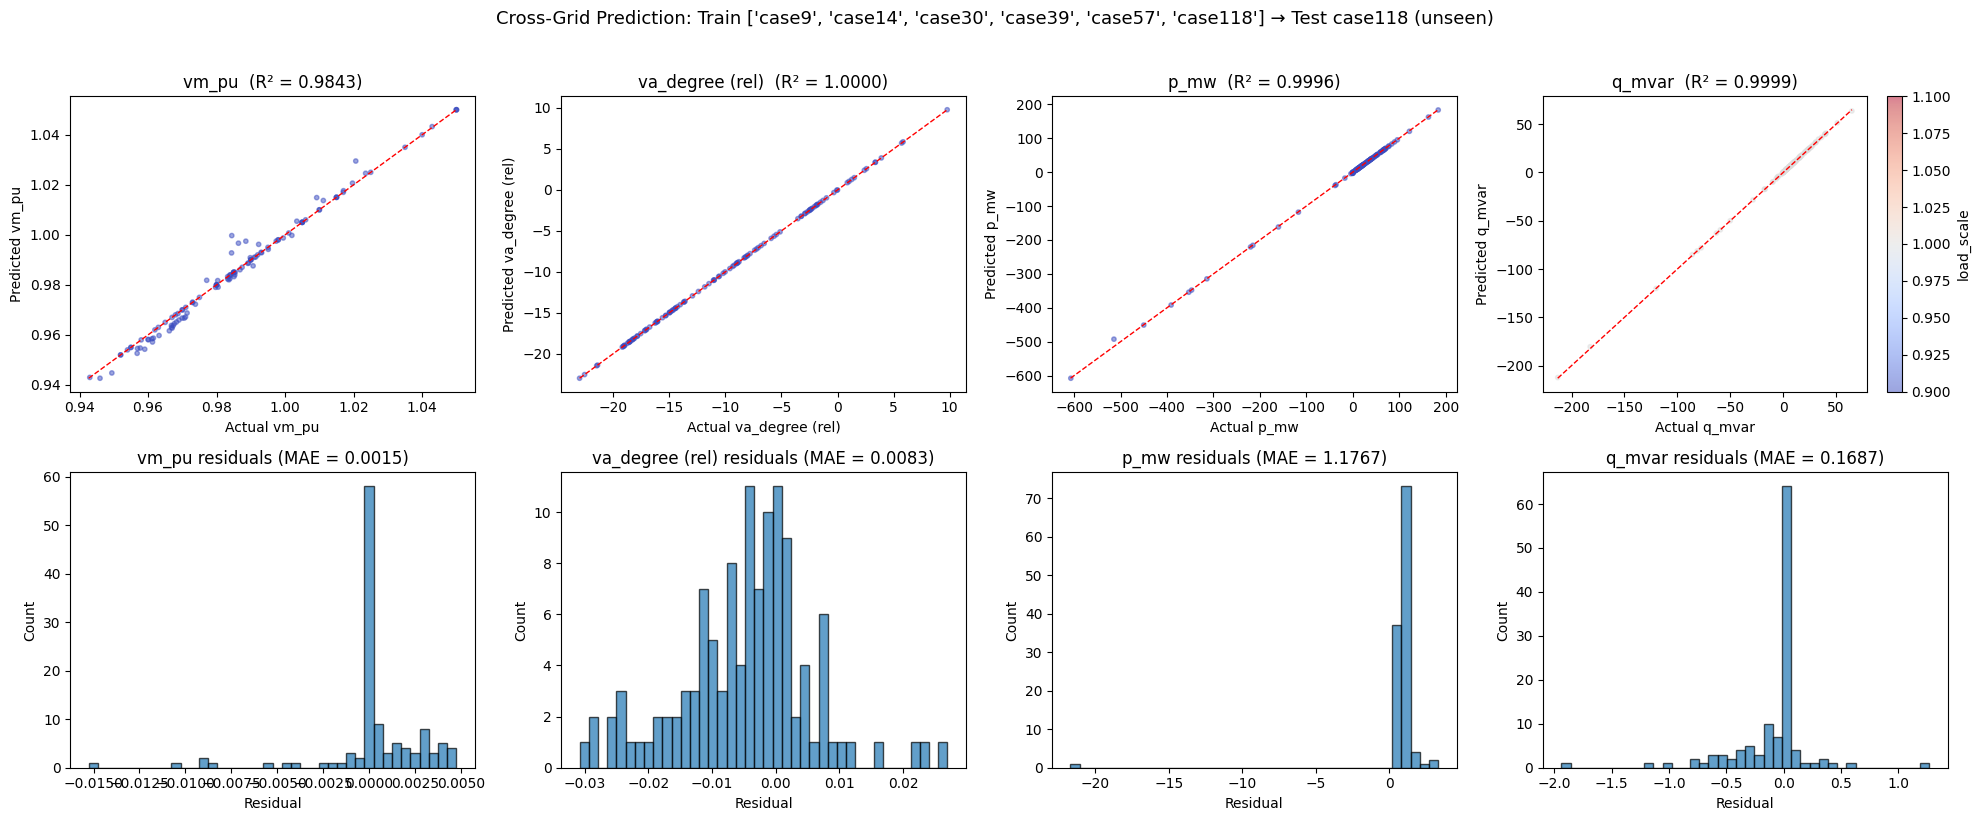

In [115]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for i, label in enumerate(original_target_labels):
    res = results[label]
    actual = res['actual']
    preds = res['preds']

    # Scatter: predicted vs actual, colored by load_scale
    ax = axes[0, i]
    sc = ax.scatter(actual, preds, c=test_df['load_scale'].values,
                    alpha=0.5, s=10, cmap='coolwarm')
    lims = [min(actual.min(), preds.min()), max(actual.max(), preds.max())]
    ax.plot(lims, lims, 'r--', linewidth=1)
    ax.set_xlabel(f'Actual {label}')
    ax.set_ylabel(f'Predicted {label}')
    ax.set_title(f'{label}  (R² = {res["r2"]:.4f})')
    if i == 3:
        plt.colorbar(sc, ax=ax, label='load_scale')

    # Residual histogram
    ax = axes[1, i]
    residuals = actual - preds
    ax.hist(residuals, bins=40, edgecolor='black', alpha=0.7)
    ax.set_xlabel('Residual')
    ax.set_ylabel('Count')
    ax.set_title(f'{label} residuals (MAE = {res["mae"]:.4f})')

plt.suptitle(f'Cross-Grid Prediction: Train {list(train_grid_loaders.keys())} → Test case118 (unseen)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 9. Per-Scale Breakdown

In [116]:
# Evaluate R² at each individual test scale
print(f"{'Scale':>6s}", end='')
for label in original_target_labels:
    print(f"  {label:>16s}", end='')
print()
print('-' * 76)

for s in test_scales:
    mask = test_df['load_scale'] == s
    print(f"{s:6.2f}", end='')
    for label in original_target_labels:
        ot = results[label]['ot']
        actual_s = test_df.loc[mask, ot].values
        preds_s  = results[label]['preds'][mask.values]
        r2_s = r2_score(actual_s, preds_s)
        print(f"  {r2_s:16.4f}", end='')
    print()

 Scale             vm_pu   va_degree (rel)              p_mw            q_mvar
----------------------------------------------------------------------------
  1.00            0.9843            1.0000            0.9996            0.9999


## 10. Error Analysis by Bus Role

Mean Absolute Error by Bus Role (scale=1.0):
                      count  mean_total    mean_vm_pu  mean_va_degree (rel)  mean_p_mw  mean_q_mvar
role                                                                                               
Slack                     1   22.957908  0.000000e+00              0.000000  21.689430     1.268478
Shunt                     2    3.636248  2.633107e-03              0.007484   3.314307     0.311824
Generator+Load+Shunt      6    1.332502  1.665335e-16              0.006219   0.918621     0.407663
Transit                   8    1.287840  8.943632e-04              0.008993   1.277953     0.000000
Generator                 8    1.268004  1.387779e-16              0.013684   0.875103     0.379217
Load+Shunt                6    1.248570  9.563114e-03              0.010655   0.838200     0.390153
Generator+Load           39    1.169675  1.622634e-16              0.008541   0.899737     0.261397
Load                     48    1.002916  2.281009e-03  

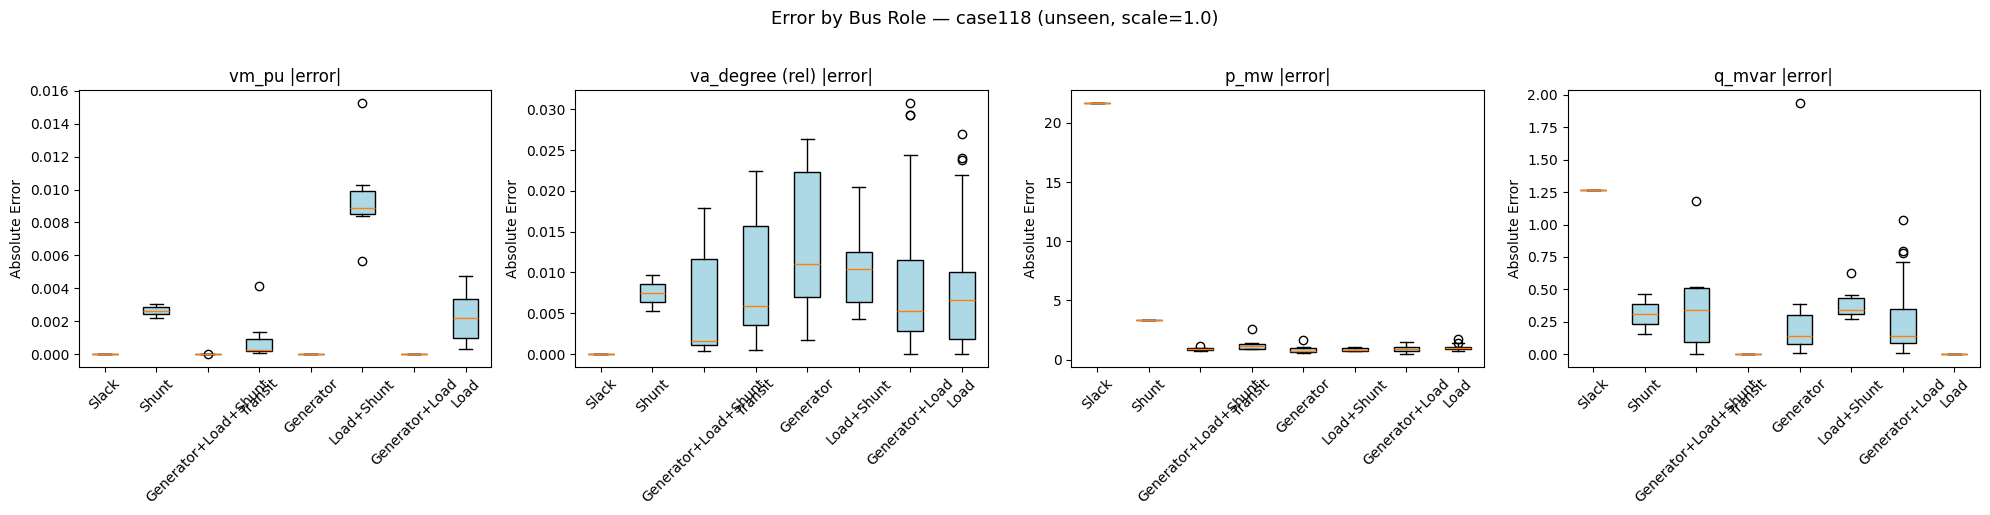

In [117]:
def get_bus_role(row):
    roles = []
    if row['is_slack']:   roles.append('Slack')
    elif row['has_gen']:  roles.append('Generator')
    if row['has_load']:   roles.append('Load')
    if row['has_shunt']:  roles.append('Shunt')
    if not roles:         roles.append('Transit')
    return '+'.join(roles)

# Build error dataframe (using scale=1.0 slice for cleaner analysis)
mask_1 = test_df['load_scale'] == 1.0
err_df = pd.DataFrame()
err_df['is_slack'] = test_df.loc[mask_1, 'is_slack'].values
err_df['has_gen']  = test_df.loc[mask_1, 'has_gen'].values
err_df['has_load'] = test_df.loc[mask_1, 'has_load'].values
err_df['has_shunt'] = test_df.loc[mask_1, 'has_shunt'].values
err_df['n_connections'] = test_df.loc[mask_1, 'n_connections'].values
err_df['role'] = err_df.apply(get_bus_role, axis=1)

for label in original_target_labels:
    ot = results[label]['ot']
    actual_1 = test_df.loc[mask_1, ot].values
    preds_1  = results[label]['preds'][mask_1.values]
    err_df[f'{label}_err'] = np.abs(actual_1 - preds_1)
err_df['total_err'] = sum(err_df[f'{label}_err'] for label in original_target_labels)

# Mean error by role
role_stats = err_df.groupby('role').agg(
    count=('total_err', 'count'),
    mean_total=('total_err', 'mean'),
    **{f'mean_{label}': (f'{label}_err', 'mean') for label in original_target_labels}
).sort_values('mean_total', ascending=False)
print("Mean Absolute Error by Bus Role (scale=1.0):")
print(role_stats.to_string())

# Box plot: error by role
roles_sorted = role_stats.index.tolist()
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, label in enumerate(original_target_labels):
    ax = axes[i]
    data = [err_df[err_df['role'] == r][f'{label}_err'].values for r in roles_sorted]
    bp = ax.boxplot(data, tick_labels=roles_sorted, vert=True, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
    ax.set_title(f'{label} |error|')
    ax.set_ylabel('Absolute Error')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Error by Bus Role — case118 (unseen, scale=1.0)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()